In [11]:
from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

In [12]:
def oracle(secret_code, n, qc):
    reversed_secrete_code = secret_code[::-1]
    for i in range(n):
        if reversed_secrete_code[i] == '1':
            qc.cx(i, n)
    qc.barrier()

In [13]:
def init_bernstein_vazirani(secret_code):
    n = len(secret_code)
    qc = QuantumCircuit(n+1, n)
    qc.h(range(n))
    qc.x(n)
    qc.h(n)
    qc.barrier()
    return secret_code, n, qc

In [14]:
def bernstein_vazirani(secret_code):
    secret_code, n, qc = init_bernstein_vazirani(secret_code)
    oracle(secret_code, n, qc)
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

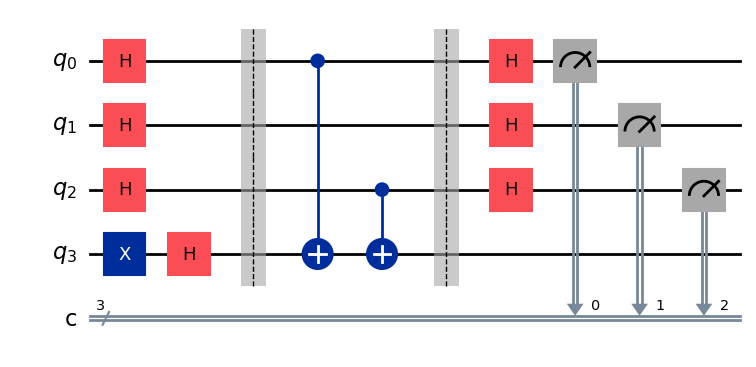

In [15]:
qc =bernstein_vazirani("101")
display(qc.draw('mpl'))